In [16]:
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
adata=sc.read("data/sc.h5ad",backup_url="https://cell2location.cog.sanger.ac.uk/paper/integrated_lymphoid_organ_scrna/RegressionNBV4Torch_57covariates_73260cells_10237genes/sc.h5ad")

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]),
 [Text(0, 0, 'B_Cycling'),
  Text(1, 0, 'B_GC_DZ'),
  Text(2, 0, 'B_GC_LZ'),
  Text(3, 0, 'B_GC_prePB'),
  Text(4, 0, 'B_IFN'),
  Text(5, 0, 'B_activated'),
  Text(6, 0, 'B_mem'),
  Text(7, 0, 'B_naive'),
  Text(8, 0, 'B_plasma'),
  Text(9, 0, 'B_preGC'),
  Text(10, 0, 'DC_CCR7+'),
  Text(11, 0, 'DC_cDC1'),
  Text(12, 0, 'DC_cDC2'),
  Text(13, 0, 'DC_pDC'),
  Text(14, 0, 'Endo'),
  Text(15, 0, 'FDC'),
  Text(16, 0, 'ILC'),
  Text(17, 0, 'Macrophages_M1'),
  Text(18, 0, 'Macrophages_M2'),
  Text(19, 0, 'Mast'),
  Text(20, 0, 'Monocytes'),
  Text(21, 0, 'NK'),
  Text(22, 0, 'NKT'),
  Text(23, 0, 'T_CD4+'),
  Text(24, 0, 'T_CD4+_TfH'),
  Text(25, 0, 'T_CD4+_TfH_GC'),
  Text(26, 0, 'T_CD4+_naive'),
  Text(27, 0, 'T_CD8+_CD161+'),
  Text(28, 0, 'T_CD8+_cytotoxic'),
  Text(29, 0, 'T_CD8+_naive'),
  Text(30, 0, 'T_TIM3+'),
  Text(31, 0, 'T_T

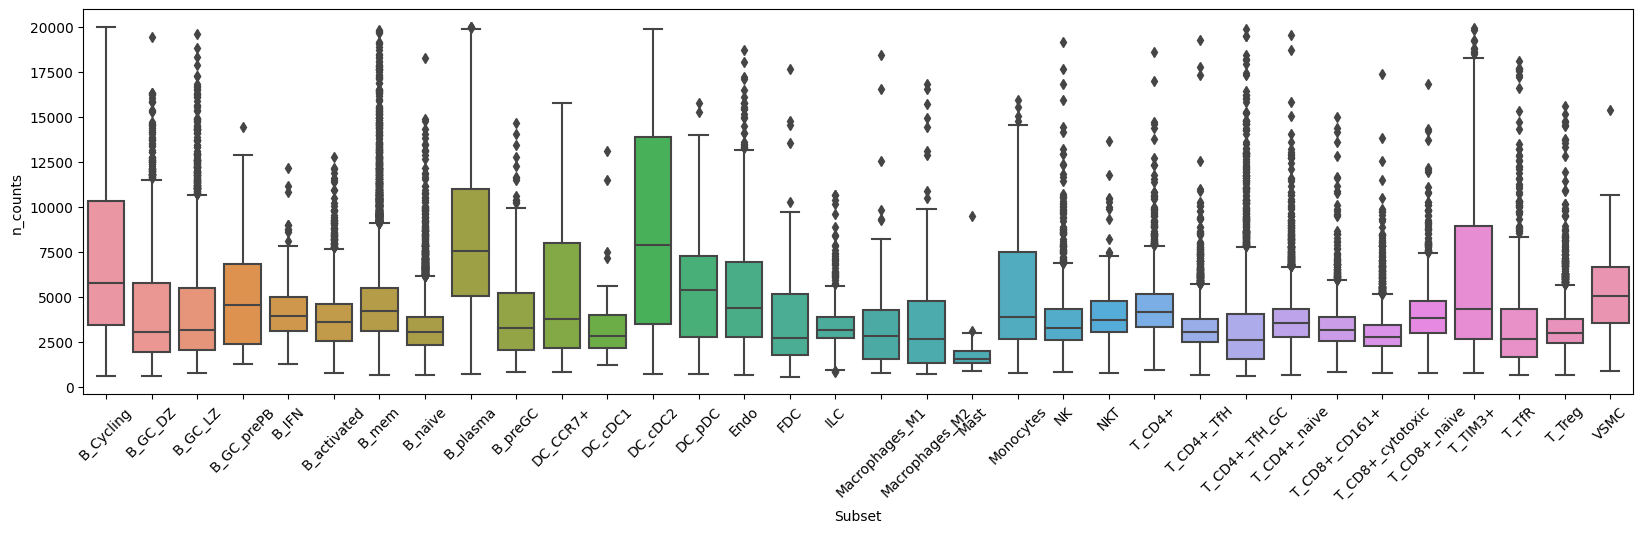

In [17]:
import seaborn as sns
from matplotlib import pyplot as plt
plt.figure(figsize=(20, 5))
sns.boxplot(adata.obs, x="Subset", y='n_counts')
plt.xticks(rotation=45)

In [27]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, flavor='seurat_v3', subset=True)
sc.pp.normalize_total(adata)
adata.layers['scaled'] = np.sqrt(adata.to_df())
celltype_means=adata.to_df('scaled').groupby(adata.obs['Subset']).mean()

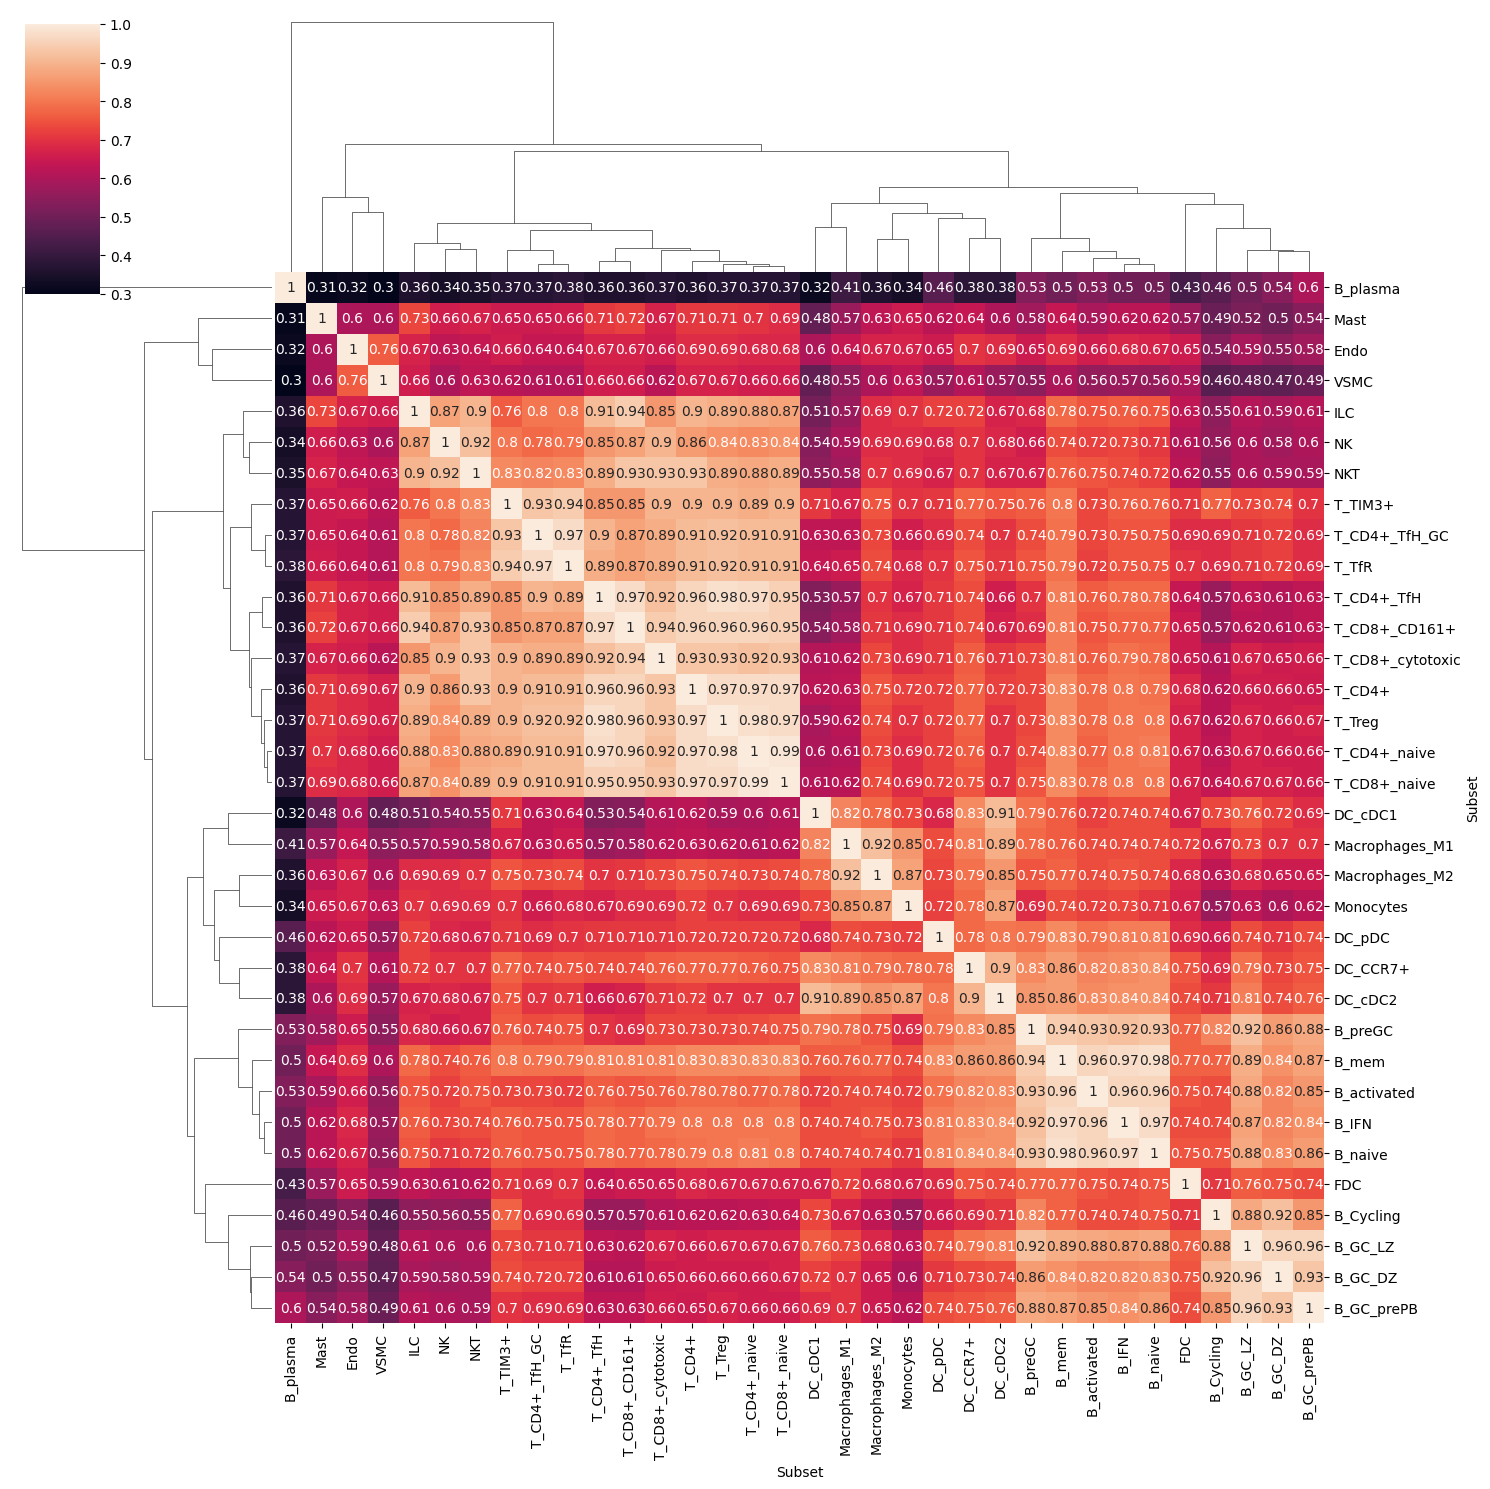

In [28]:
sns.clustermap(celltype_means.T.corr().round(2), annot=True, figsize=(15,15))

In [19]:
sc.pp.filter_cells(adata1,min_counts=2000)
def subsample_celltype(adata, obs_name="cell_types", n_cells=700, random_state=0):
    '''
    Subsets data set to contain no more than a given amount of any one cell type.
    Parameters
    ----------
    adata : AnnData
        input dataset
    obs_name : str, optional
        field in `adata.obs` corresponding to cell types.  Default: "cell_types"
    n_cells : int, optional
        maximum number of cells for any cell type.
    random_state : int, optional
        seed used for reproducibility.
    Returns
    -------
    adata : AnnData
        subsampled dataset
    '''

    adatas=dict()
    for ct in np.unique(adata.obs[obs_name]):
        adatas[ct]=adata[(adata.obs[obs_name] == ct)]
        if adatas[ct].n_obs>n_cells:
            adatas[ct]=sc.pp.subsample(adatas[ct], n_obs=n_cells, random_state=random_state, copy=True)
    return ad.concat(adatas, label="cell_types")
adata=subsample_celltype(adata1, obs_name="CellType", n_cells=700)

AnnData object with n_obs × n_vars = 23481 × 10237
    obs: 'Age', 'BCELL_CLONE', 'BCELL_CLONE_SIZE', 'Donor', 'ID', 'IGH_MU_FREQ', 'ISOTYPE', 'LibraryID', 'Method', 'Population', 'PrelimCellType', 'Sample', 'Sex', 'Study', 'Tissue', 'barcode', 'batch', 'doublet_score', 'index', 'predicted_doublet', 'percent_mito', 'n_counts', 'n_genes', 'S_score', 'G2M_score', 'phase', 'VDJsum', 'cell_cycle_diff', 'PrelimCellType_new', 'leiden', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'CellType', 'CellType2', 'Subset', 'Subset_Broad', 'Subset_all', 'new_celltype', 'Subset_int', 'Subset_print', 'cell_types'
    obsm: 'X_pca', 'X_umap'

In [5]:
import stan
adata=stan.pp.tf_gene(adata,
                min_cells_proportion = 0.1,
                min_tfs_per_gene= 5,
                min_genes_per_tf= 10,
                max_proportion_genes_per_tf= 0.8,
                tf_gene_source="hTFtarget",
                tf_list="humantfs",
                inplace = False,
                source_dir="data/tf_gene/")

OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/student/Library/CloudStorage/OneDrive-UniversityofPittsburgh/code/stan/stan/pp/tf_gene.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf_gene['values']=1
/Users/student/Library/CloudStorage/OneDrive-UniversityofPittsburgh/code/stan/stan/pp/tf_gene.py:155: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  tf_gene.drop(tf_gene.index[gene_sum<min_tfs_per_gene], 0,inplace=True)
/Users/student/Library/CloudStorage/OneDrive-UniversityofPittsburgh/code/stan/stan/pp/tf_gene.py:156: FutureWarning: In a future version of pandas all arguments of DataFrame.drop excep

In [6]:
sc.pp.normalize_total(adata)
adata.layers['scaled'] = np.sqrt(adata.to_df())
stan.pp.assign_folds(adata, n_folds=10)
print(adata)

AnnData object with n_obs × n_vars = 23481 × 4385
    obs: 'Age', 'BCELL_CLONE', 'BCELL_CLONE_SIZE', 'Donor', 'ID', 'IGH_MU_FREQ', 'ISOTYPE', 'LibraryID', 'Method', 'Population', 'PrelimCellType', 'Sample', 'Sex', 'Study', 'Tissue', 'barcode', 'batch', 'doublet_score', 'index', 'predicted_doublet', 'percent_mito', 'n_counts', 'n_genes', 'S_score', 'G2M_score', 'phase', 'VDJsum', 'cell_cycle_diff', 'PrelimCellType_new', 'leiden', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'CellType', 'CellType2', 'Subset', 'Subset_Broad', 'Subset_all', 'new_celltype', 'Subset_int', 'Subset_print', 'cell_types'
    var: 'n_cells', 'fold'
    uns: 'tf_names'
    obsm: 'X_pca', 'X_umap'
    varm: 'tf_gene'
    layers: 'scaled'


In [7]:
stl_model=stan.models.SpaTraFact_stl(adata, layer='scaled', intercept=False)
stl_model.fit(n_steps=5,
              stages=1,
              grid_search_params={'lambda1':[1e-6, 1e6]},
              axis=0,
              verbose=False)
print(stl_model.evaluate(fold=-1, return_string=True))
adata.obs['pred_cor_stl']=stl_model.evaluate(fold=-1)[0]
adata.var['pred_cor_stl']=stl_model.evaluate(fold=-1)[1]
adata.obsm['tfa']=pd.DataFrame(stl_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

Sample Cor:0.154 Gene Cor: 0.086


In [11]:
adata.write("out/sc_tfa.h5ad")

adata_tfa = ad.AnnData(X=adata.obsm["tfa"], obs=adata.obs)
adata_tfa.var_names = adata.uns['tf_names']
adata_tfa.write("out/sc_tfa_only.h5ad")

/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_85560/3855632879.py:3: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_tfa = ad.AnnData(X=adata.obsm["tfa"], obs=adata.obs)


In [ ]:
adata_tfa

In [34]:
adata_tfa_vis=sc.read_h5ad("out/stf_results_tfa_only.h5ad")

In [ ]:
adata_tfa_vis

In [ ]:
sc.pp.scale(adata_tfa)
sc.pp.scale(adata_tfa_vis)

sc_df=adata_tfa.to_df()
st_df=adata_tfa_vis.to_df()

tf_names=np.intersect1d(sc_df.columns, st_df.columns)
sc_df=sc_df[tf_names]
st_df=st_df[tf_names]

In [ ]:
sc_score=sc_df.groupby(adata.obs['Subset']).mean().T

In [32]:
adata.obs["Subset"].unique()

array(['B_Cycling', 'B_GC_DZ', 'B_GC_LZ', 'B_GC_prePB', 'B_activated',
       'B_preGC', 'B_mem', 'B_IFN', 'B_naive', 'B_plasma', 'DC_CCR7+',
       'DC_cDC2', 'DC_cDC1', 'Endo', 'ILC', 'Mast', 'Macrophages_M2',
       'Macrophages_M1', 'Monocytes', 'NKT', 'NK', 'T_TIM3+',
       'T_CD4+_naive', 'T_CD4+', 'T_CD8+_cytotoxic', 'T_CD8+_CD161+',
       'T_CD8+_naive', 'T_CD4+_TfH_GC', 'T_CD4+_TfH', 'T_Treg', 'T_TfR',
       'DC_pDC', 'VSMC', 'FDC'], dtype=object)

In [41]:
adata_tfa_vis.obsm['celltype'].max()

B_Cycling           0.322178
B_GC_DZ             0.191073
B_GC_LZ             0.251917
B_GC_prePB          0.073609
B_IFN               0.393843
B_activated         0.104436
B_mem               0.362801
B_naive             0.463973
B_plasma            0.221952
B_preGC             0.282343
DC_CCR7+            0.063498
DC_cDC1             0.158705
DC_cDC2             0.081908
DC_pDC              0.065160
Endo                0.125348
FDC                 0.143231
ILC                 0.065045
Macrophages_M1      0.150473
Macrophages_M2      0.102280
Mast                0.065490
Monocytes           0.056502
NK                  0.100312
NKT                 0.041749
T_CD4+              0.056602
T_CD4+_TfH          0.066354
T_CD4+_TfH_GC       0.175265
T_CD4+_naive        0.586360
T_CD8+_CD161+       0.037474
T_CD8+_cytotoxic    0.107737
T_CD8+_naive        0.087122
T_TIM3+             0.160385
T_TfR               0.092291
T_Treg              0.137143
VSMC                0.384671
dtype: float64

In [30]:
['B_Cycling',
 ['B_GC_DZ',
 'B_GC_LZ',
 'B_GC_prePB'],
 'B_activated',
 'B_preGC',
 'B_mem',
 'B_IFN',
 'B_naive',
 'B_plasma',
 ['DC_CCR7+',
 'DC_cDC2',
 'DC_cDC1',
  'DC_pDC'],
 'Endo',
 'Mast',
 ['Macrophages_M2',
 'Macrophages_M1',
 'Monocytes'],
 ['NKT',
 'NK',
 'ILC'],
 'T_TIM3+',
 ['T_CD8+_cytotoxic',
 'T_CD8+_CD161+',
 'T_CD8+_naive'],
 ['T_CD4+_naive',
  'T_CD4+_TfH_GC',
 'T_CD4+_TfH',
 'T_CD4+'],
 'T_Treg',
 'T_TfR',
 'VSMC',
 'FDC']

20

In [ ]:
vis_score=np.linalg.pinv(adata_tfa_vis.obsm['celltype']).dot(st_df).T
vis_score=pd.DataFrame(vis_score, columns=adata_tfa_vis.obsm['celltype'].columns, index=st_df.columns)

In [ ]:
vis_score

In [ ]:
sc_score=(sc_score-sc_score.mean())/sc_score.std()
vis_score=(vis_score-vis_score.mean())/vis_score.std()

In [ ]:
from scipy.cluster.hierarchy import linkage

link_mat=linkage(sc_score.T, metric='correlation')

sns.clustermap(sc_score.T.dot(vis_score)/176,col_cluster=False, row_cluster=False)

In [ ]:
sc.pp.filter_genes(adata1, min_cells=200)
ct_gene_mean=adata1.to_df().groupby(adata.obs["Subset"]).mean().T
ct_gene_mean_scaled=(ct_gene_mean-ct_gene_mean.mean())/ct_gene_mean.std()

In [ ]:
sns.clustermap(ct_gene_mean_scaled.T.dot(ct_gene_mean_scaled)/adata1.n_vars)

In [ ]:
ct_gene_mean_scaled